## Feature Engineering - Hour

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

In [2]:
# Load data
df_hour = pd.read_csv('hour.csv')
print(f"Original dataset shape: {df_hour.shape}")
df_hour.head()

Original dataset shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## Data Cleaning & Preprocessing

In [3]:
# Parse date and keep day component
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])
df_hour['day'] = df_hour['dteday'].dt.day

# Drop identifiers
df_hour.drop(['instant', 'dteday'], axis=1, inplace=True)

print('After initial cleaning:', df_hour.shape)

After initial cleaning: (17379, 16)


## Remove Target Leakage Features

In [4]:
# Remove columns that leak target information
leakage_cols = ['casual', 'registered']
df_hour.drop(leakage_cols, axis=1, inplace=True, errors='ignore')
print('Removed leakage columns:', leakage_cols)
print('Current columns:', df_hour.columns.tolist())

Removed leakage columns: ['casual', 'registered']
Current columns: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'day']


## Feature Engineering

In [5]:
# Weekend flag
df_hour['is_weekend'] = df_hour['weekday'].apply(lambda x: 1 if x in [0, 6] else 0)

# Peak-hour flag
def is_peak_hour(hr):
    if (7 <= hr <= 9) or (17 <= hr <= 19):
        return 1
    return 0
df_hour['is_peak_hour'] = df_hour['hr'].apply(is_peak_hour)

# Time-of-day buckets + one-hot
def time_of_day(hr):
    if 5 <= hr <= 11:
        return 'morning'
    elif 12 <= hr <= 16:
        return 'afternoon'
    elif 17 <= hr <= 20:
        return 'evening'
    else:
        return 'night'
df_hour['time_of_day'] = df_hour['hr'].apply(time_of_day)
df_hour = pd.get_dummies(df_hour, columns=['time_of_day'], drop_first=True, dtype=int)

# Cyclic encodings
df_hour['hr_sin'] = np.sin(2 * np.pi * df_hour['hr'] / 24)
df_hour['hr_cos'] = np.cos(2 * np.pi * df_hour['hr'] / 24)
df_hour['weekday_sin'] = np.sin(2 * np.pi * df_hour['weekday'] / 7)
df_hour['weekday_cos'] = np.cos(2 * np.pi * df_hour['weekday'] / 7)
df_hour['mnth_sin'] = np.sin(2 * np.pi * df_hour['mnth'] / 12)
df_hour['mnth_cos'] = np.cos(2 * np.pi * df_hour['mnth'] / 12)
df_hour['day_sin'] = np.sin(2 * np.pi * df_hour['day'] / 31)
df_hour['day_cos'] = np.cos(2 * np.pi * df_hour['day'] / 31)

# Drop original cyclical integer columns
df_hour.drop(['hr', 'weekday', 'mnth', 'day'], axis=1, inplace=True)

# One-hot for season and weather
df_hour = pd.get_dummies(df_hour, columns=['season', 'weathersit'], drop_first=True, dtype=int)

# Interaction and polynomial features
df_hour['temp_humidity'] = df_hour['temp'] * df_hour['hum']
df_hour['temp_windspeed'] = df_hour['temp'] * df_hour['windspeed']
df_hour['humidity_windspeed'] = df_hour['hum'] * df_hour['windspeed']
df_hour['temp_squared'] = df_hour['temp'] ** 2
df_hour['holiday_workday'] = df_hour['holiday'] * df_hour['workingday']

# Composite comfort metric
df_hour['temp_comfort'] = df_hour['temp'] * (1 - df_hour['hum'])

print(f"After feature engineering: {df_hour.shape}")
print(f"Columns now: {len(df_hour.columns)}")

After feature engineering: (17379, 33)
Columns now: 33


## Check for Multicollinearity

In [6]:
correlation_matrix = df_hour.corr()
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        col_i = correlation_matrix.columns[i]
        col_j = correlation_matrix.columns[j]
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.85 and col_i != 'cnt' and col_j != 'cnt':
            high_corr_pairs.append((col_i, col_j, corr_val))

if high_corr_pairs:
    print('High-correlation pairs (|corr| > 0.85):')
    for col1, col2, corr in high_corr_pairs:
        print(f'  {col1} <-> {col2}: {corr:.3f}')
else:
    print('No highly correlated feature pairs found')

target_corr = correlation_matrix['cnt'].drop('cnt').sort_values(ascending=False)
print('Top 10 features by correlation with target:')
print(target_corr.head(10))

High-correlation pairs (|corr| > 0.85):
  workingday <-> is_weekend: -0.934
  temp <-> atemp: 0.988
  temp <-> temp_squared: 0.981
  atemp <-> temp_squared: 0.962
Top 10 features by correlation with target:
temp_comfort           0.502766
is_peak_hour           0.453926
time_of_day_evening    0.412597
temp                   0.404772
atemp                  0.400929
temp_squared           0.399565
temp_windspeed         0.306052
yr                     0.250495
season_3               0.151621
windspeed              0.093234
Name: cnt, dtype: float64


## Prepare Features and Target

In [7]:
X = df_hour.drop('cnt', axis=1).copy()
y = df_hour['cnt'].copy()
print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')

Features shape: (17379, 32)
Target shape: (17379,)


## Feature Selection with Cross-Validation

In [8]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
feature_importance_cv = pd.DataFrame({'Feature': X.columns, 'Importance_Mean': 0.0, 'Importance_Std': 0.0})
all_importances = {col: [] for col in X.columns}
fold = 1
for train_idx, test_idx in kfold.split(X):
    X_train_fold = X.iloc[train_idx]
    X_test_fold = X.iloc[test_idx]
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1, max_depth=15)
    rf.fit(X_train_fold, y_train_fold)
    perm = permutation_importance(rf, X_test_fold, y_test_fold, n_repeats=10, random_state=42)
    for feature, imp in zip(X.columns, perm.importances_mean):
        all_importances[feature].append(imp)
    print(f'Fold {fold} completed')
    fold += 1
for feature in X.columns:
    feature_importance_cv.loc[feature_importance_cv['Feature'] == feature, 'Importance_Mean'] = np.mean(all_importances[feature])
    feature_importance_cv.loc[feature_importance_cv['Feature'] == feature, 'Importance_Std'] = np.std(all_importances[feature])
feature_importance_cv = feature_importance_cv.sort_values('Importance_Mean', ascending=False).reset_index(drop=True)
print('Cross-Validation Feature Importance (Top 20):')
print(feature_importance_cv.head(20))

Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed
Cross-Validation Feature Importance (Top 20):
                Feature  Importance_Mean  Importance_Std
0                hr_cos         0.694279        0.013327
1                hr_sin         0.344923        0.009181
2                    yr         0.193778        0.003045
3            workingday         0.144555        0.012663
4   time_of_day_evening         0.051181        0.003381
5            is_weekend         0.048525        0.012819
6          temp_squared         0.035542        0.002198
7                  temp         0.034457        0.002219
8          temp_comfort         0.033757        0.003238
9              season_4         0.025779        0.001803
10         is_peak_hour         0.018499        0.000798
11             mnth_sin         0.016767        0.001164
12                atemp         0.014118        0.000939
13         weathersit_3         0.013376        0.001247
14          we

## Select Features (Threshold + Domain)

In [9]:
importance_threshold = 0.002
domain_features = ['temp', 'hum', 'windspeed', 'workingday', 'holiday', 'is_weekend', 'is_peak_hour']
important_features = feature_importance_cv[feature_importance_cv['Importance_Mean'] > importance_threshold]['Feature'].tolist()
selected_features = list(set(important_features + [f for f in domain_features if f in X.columns]))
selected_features.sort()
print(f'Selected {len(selected_features)} features using threshold {importance_threshold}:')
print(selected_features)
removed_features = [f for f in X.columns if f not in selected_features]

for f in removed_features:
    imp = feature_importance_cv[feature_importance_cv['Feature'] == f]['Importance_Mean'].values[0]
    print(f'  {f}: {imp:.6f}')

Selected 24 features using threshold 0.002:
['atemp', 'day_sin', 'holiday', 'hr_cos', 'hr_sin', 'hum', 'humidity_windspeed', 'is_peak_hour', 'is_weekend', 'mnth_cos', 'mnth_sin', 'season_4', 'temp', 'temp_comfort', 'temp_humidity', 'temp_squared', 'time_of_day_evening', 'time_of_day_morning', 'weathersit_3', 'weekday_cos', 'weekday_sin', 'windspeed', 'workingday', 'yr']
  time_of_day_night: 0.000075
  day_cos: 0.001884
  season_2: 0.001293
  season_3: 0.000193
  weathersit_2: 0.000117
  weathersit_4: 0.000000
  temp_windspeed: 0.000353
  holiday_workday: 0.000000


## Create Final Dataset

In [10]:
df_final = df_hour[selected_features + ['cnt']].copy()
df_final.to_csv('hour_dataset_featured_new.csv', index=False)
print('Saved improved dataset to: hour_dataset_featured_improved.csv')
print(f'Final dataset shape: {df_final.shape}')
print(f'Selected features: {len(selected_features)}')

Saved improved dataset to: hour_dataset_featured_improved.csv
Final dataset shape: (17379, 25)
Selected features: 24


## Visualize Feature Selection Results

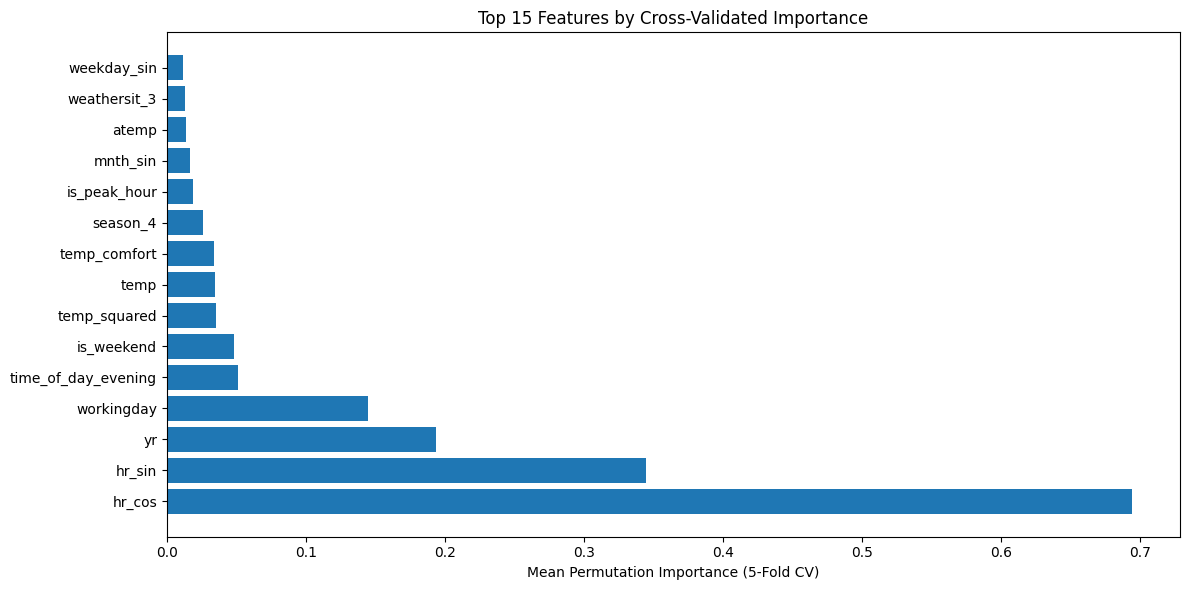

Feature selection visualization complete


In [11]:
plt.figure(figsize=(12, 6))
top_features = feature_importance_cv.head(15)
plt.barh(range(len(top_features)), top_features['Importance_Mean'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Mean Permutation Importance (5-Fold CV)')
plt.title('Top 15 Features by Cross-Validated Importance')
plt.tight_layout()
plt.show()
print('Feature selection visualization complete')